In [ ]:
import pip


%pip install kagglehub[pandas-datasets]
%pip install openpyxl #Instalando dependência para abrir .XLSX
%pip install matplotlib

In [9]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib as plt
import openpyxl as opn 

Carregando diretamente do Kaggle

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = 'iFood.xlsx'

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fayez7/ifood-marketing-campaigns",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

In [18]:
pd.DataFrame(df, columns=['Index','Income','Age' , 'Customer_Days' , 'MntTotal']).sort_values(by='MntTotal', ascending=True) 
#Quanto maior a Renda (Income) maior o gasto total(MntTotal)? 

,Index,Income,Age,Customer_Days,MntTotal
1499,2500,3502,47,2601,4
961,1962,4861,55,2166,5
2097,3098,33590,46,2397,6
1225,2226,1730,49,2201,7
1395,2396,34578,48,2238,8
...,...,...,...,...,...
967,1968,75759,51,2406,2304
1433,2434,93790,50,2296,2304
1159,2160,90638,29,2295,2429
1547,2548,90638,29,2295,2429


In [17]:
df[df['Index'] > 2468] # Forma de Localizar/Filtrar um Registro

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education
1468,2469,57867,1,0,48,344,35,178,15,23,...,0,0,0,0,0,0,42,2430,Together,Graduation
1469,2470,35765,1,0,86,22,3,30,0,5,...,0,0,0,0,0,0,30,2359,Married,Graduation
1470,2471,65492,0,0,73,247,161,295,210,85,...,0,0,0,0,0,0,61,2313,Married,Graduation
1471,2472,32952,1,0,36,38,0,12,3,1,...,0,0,0,0,0,0,43,2369,Divorced,Graduation
1472,2473,53374,0,1,34,896,10,101,13,10,...,0,1,0,0,1,0,51,2841,Together,PHD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,3201,61223,0,1,46,709,43,182,42,118,...,0,0,0,0,0,0,53,2540,Married,Graduation
2201,3202,64014,2,1,56,406,0,30,0,0,...,0,0,0,0,1,0,74,2178,Together,PHD
2202,3203,56981,0,0,91,908,48,217,32,12,...,0,0,1,0,1,0,39,2314,Divorced,Graduation
2203,3204,69245,0,1,8,428,30,214,80,30,...,0,0,0,0,0,0,64,2315,Together,Master


In [19]:
df['upper_1k'] = df['MntTotal'] >= 1000 # Criando uma coluna que o valor gasto seja maior que 1k

Retornando gastos abaixo de 1k

In [21]:
pd.DataFrame(df[df['upper_1k'] == False], columns=['Index','Income','Age' , 'Customer_Days' , 'MntTotal', 'upper_1k']).sort_values(by='MntTotal', ascending=True) 

,Index,Income,Age,Customer_Days,MntTotal,upper_1k
1499,2500,3502,47,2601,4,False
961,1962,4861,55,2166,5,False
2097,3098,33590,46,2397,6,False
1225,2226,1730,49,2201,7,False
1820,2821,4023,57,2165,8,False
...,...,...,...,...,...,...
1482,2483,46772,45,2758,991,False
1845,2846,69932,56,2541,992,False
156,1157,66951,32,2398,993,False
1774,2775,78416,44,2161,996,False


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'MntTotal'}>],
       [<Axes: title={'center': 'Income'}>, <Axes: >]], dtype=object)

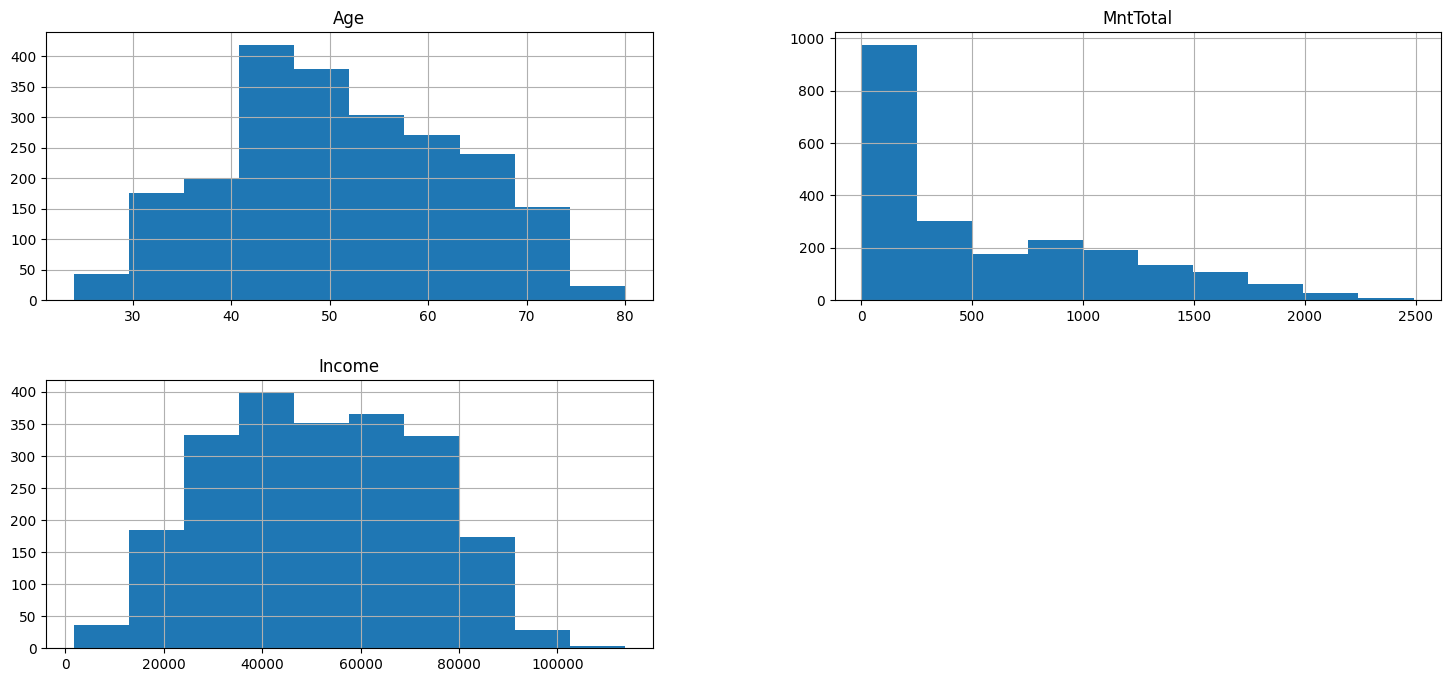

In [27]:
df.hist(column= ['Age', 'MntTotal','Income'], figsize=(18,8))